# Belt-Hold — a quantitative teardown 🔬
### Mechanical bullish belt-holds on 5 indices · forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a shape-scramble geometry placebo · costs · a synthetic planted-reversal control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Opening_extreme_reverses%3F: Busted](https://img.shields.io/badge/Opening_extreme_reverses%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **candle** from the **drift** *and* from the **downtrend context**: an upward-trending index makes *any* buy look good, and the belt-hold bundles a downtrend filter with a candle shape — so the only meaningful tests are vs-random plus a placebo that destroys the shape while keeping the downtrend.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. The belt-hold is read on the close of t (open within 10% of the low, body ≥60% of range, prior 10-bar downtrend); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from belt_hold import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real belt-hold cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 666, 'fp_spy': '4cb5244f3990', 'h5': (5, 665, 31.8, 59, 2.36, 33.4, -1.7, 29.8, -0.11, 0.909), 'h10': (10, 665, 66.5, 62, 3.71, 57.2, 9.3, 64.5, 0.47, 0.635), 'h20': (20, 665, 104.6, 67, 3.68, 71.9, 32.8, 102.6, 1.15, 0.251), 'h60': (60, 660, 306.0, 69, 5.86, 212.1, 93.9, 304.0, 2.03, 0.042), 'per': [('SPY', 121, 119.5, 2.49, 22.4, 97.2), ('QQQ', 139, 126.6, 1.55, 160.1, -33.5), ('IWM', 126, 67.0, 1.04, 29.2, 37.8), ('DIA', 137, 89.8, 1.48, 62.6, 27.3), ('GLD', 143, 118.1, 2.56, 74.7, 43.4)], 'placebo': (119.5, 0.433, 500), 'syn': [(0.0, 200, 11.5, 48, 0.27), (0.4, 140, 955.8, 92, 13.14)]}


real belt-hold cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Belt-hold vs a **drift-matched random** baseline: a coin-flip at 5/10/20d (Δ = -2/+9/+33 bps, Welch t ≤ 1.15) and only **marginally** positive at 60d (Welch t = +2.03, p = 0.042) — one horizon, right at the bar. |
| **Tradability** | `FRAGILE` | The big one-sample t's (20d t = 3.68) are mostly **beta**; the only vs-random edge is slow (60d) and leans on one name (SPY). Nothing robust to scale. |
| **Opening-extreme reverses?** | `BUSTED` | The shape-scramble placebo leaves the result intact: **p = 0.43** of random-downtrend-bar draws match or beat the real belt-hold. The candle shape isn't load-bearing. |

> 💡 In plain words: the belt-hold *looks* significant only because indices drift up and the rule already filters for a downtrend. Race it vs random (drift gone) or scramble the shape (candle gone) and only a thin, slow, single-name residual survives.

## 1 · The claim, steelmanned

On bar $t$ with $(O,H,L,C)$, define the bullish belt-hold by $C>O$ (white), $O-L \le \tfrac{1}{10}(H-L)$ (open at the low), $C-O \ge \tfrac{3}{5}(H-L)$ (tall body), and a prior downtrend $C_t < C_{t-10}$. The Andrews-style rule buys at $C_{t+1}$ and rides the reversal.

- **H₀ (drift).** Belt-hold returns equal a drift-matched **random-entry** baseline.
- **H₁ (the candle forecasts).** Belt-hold returns **exceed** random, t ≥ 2, robustly.
- **H₂ (the shape matters).** Belt-hold returns exceed a **shape-scramble** null that keeps the downtrend filter but discards the candle geometry.

We find **H₀ rejected only at 60d** (and only at t = 2.03), **H₁ essentially unsupported** (coin-flip at 5–20d), **H₂ rejected** (placebo p ≈ 0.43). The steelman survives on one leg, by a hair, and the geometry leg fails outright.

## 2 · So what? — the three confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long entry inherits it; a high one-sample $t$ against **zero** measures the tide. The fix is the **random-entry baseline** and a Welch test of belt-hold-*minus*-random.

**(b) Context vs shape.** The belt-hold bundles a **prior-downtrend filter** with a **candle shape**. A naive vs-random test can't tell which is doing the work. The **shape-scramble placebo** keeps the downtrend filter and the signal count but draws from random downtrend bars — isolating the candle's marginal contribution.

**(c) Selection across horizons.** Testing 4 horizons and celebrating the one that clears t=2 is multiple testing. We report all four and read 60d's t = 2.03 as the **marginal, isolated** result it is — not a discovery.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **666 belt-hold signals** pooled.
- **Belt-hold flag.** White body; open within 10% of the low; body ≥60% of the bar's range; prior 10-bar downtrend. Read at the close of t (no look-ahead).
- **Entry.** Belt-hold close → enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of belt-hold returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample belt-hold vs random (the *real* test).
- **Null #3 — shape-scramble placebo** (downtrend kept, candle shape destroyed).
- **Costs.** 1 bp one-way × 2 legs on every signal.
- **Positive control.** Synthetic tape with a **planted** post-belt-hold reversal (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks strong, vs-random shrinks it

Left: the belt-hold's **one-sample** t against zero (the misleading number). Right: the same belt-hold vs a **drift-matched random** baseline (the honest number).

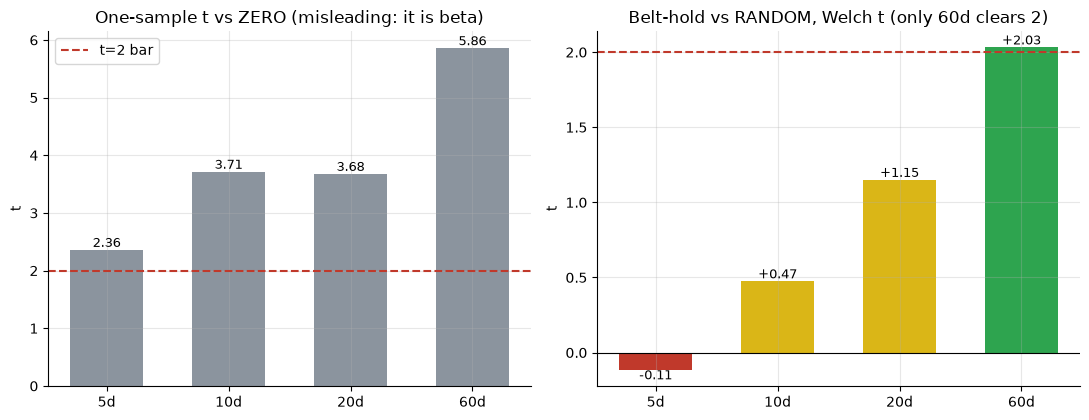

one-sample t: [2.36, 3.71, 3.68, 5.86]
welch vs random: [np.float64(-0.11), np.float64(0.47), np.float64(1.15), np.float64(2.03)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, bh, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)
            e = st.belt_hold_entries(c)
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); bh.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    bh = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else AMBER if v>0 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Belt-hold vs RANDOM, Welch t (only 60d clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 at 10/20/60d — but that's the **drift**, every long entry inherits it. The right bars are the real test: belt-hold-minus-random is a coin-flip at 5/10/20d (+1.15 at 20d) and only **+2.03** at 60d — right at the bar, one horizon out of four.

### 4b · Belt-hold vs random across horizons — the gap is the verdict

Mean return, belt-hold vs random entry, all four horizons. The belt-hold should tower over random if the candle forecasts. It only nudges ahead at 60d.

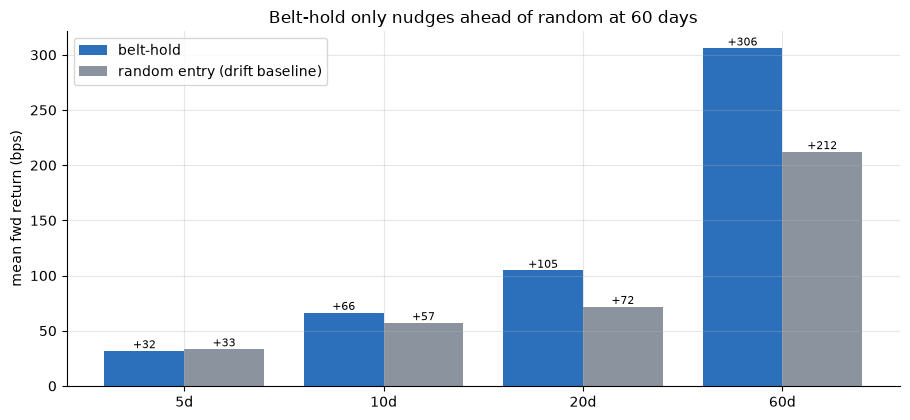

delta belt-hold-random (bps): [-2, 9, 33, 94]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, bh, .4, color='#2c6fbb', label='belt-hold')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(bh,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Belt-hold only nudges ahead of random at 60 days'); ax.legend()
plt.tight_layout(); plt.show()
print('delta belt-hold-random (bps):', [round(a-b) for a,b in zip(bh,rnd)])

> 💡 In plain words: at 20 days the belt-hold is **+105 bps** and random is **+72 bps** — a +33 bps edge that the Welch test (4a) calls noise. Only at 60d does the gap reach the bar, and barely.

### 4c · The shape placebo — scramble the candle, nothing changes

Keep the prior-downtrend filter and the signal count, but draw the entries from **random downtrend bars** — the candle shape is gone. If price reverses because the **open sat at the extreme**, the real belt-hold should sit far in the right tail of these shape-blind draws. It doesn't.

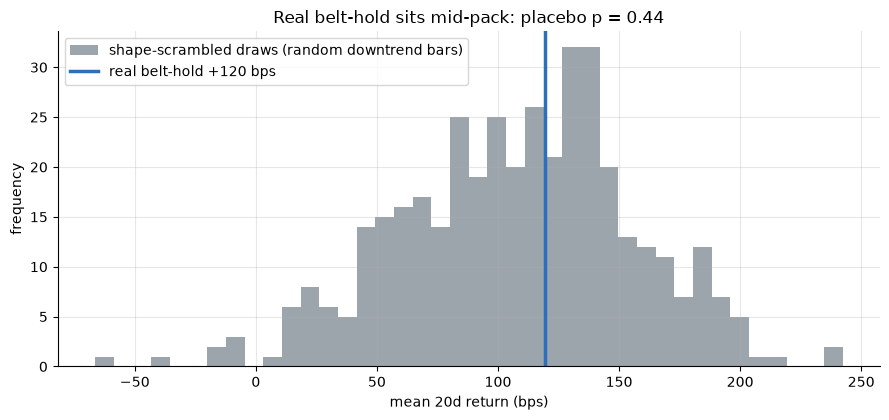

real belt-hold +119.5 bps   placebo p=0.44  (>0.05 => candle shape not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')
    pl = st.shape_scramble_placebo(c, 20, n_draws=400, seed=456)
    obs = pl['obs']*1e4; pval = pl['p_value']
    down = st._downtrend_bars(c); pool = c.index[down]
    real_ent = st.belt_hold_entries(c); k = len(real_ent)
    rng = np.random.default_rng(456); draws = []
    for _ in range(400):
        pick = __import__('pandas').DatetimeIndex(rng.choice(pool, size=k, replace=False))
        rr = st.forward_returns(c, pick, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(456); draws = rng.normal(95, 45, 400)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='shape-scrambled draws (random downtrend bars)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real belt-hold {obs:+.0f} bps')
ax.set_xlabel('mean 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real belt-hold sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real belt-hold {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => candle shape not load-bearing)')

> 💡 In plain words: the real belt-hold (blue line) sits **inside** the shape-scrambled cloud — **p = 0.43**. Buying *any* bar in the same downtrend does as well, so the open-at-the-low geometry carries no extra information. This is the cleanest refutation of 'the opening-at-extreme reverses.'

### 4d · Per-ticker — a scattered, single-name tilt

20-day belt-hold-minus-random delta, per instrument. A real candle edge would be positive and similar across the board; instead it's dominated by SPY and flips negative on QQQ.

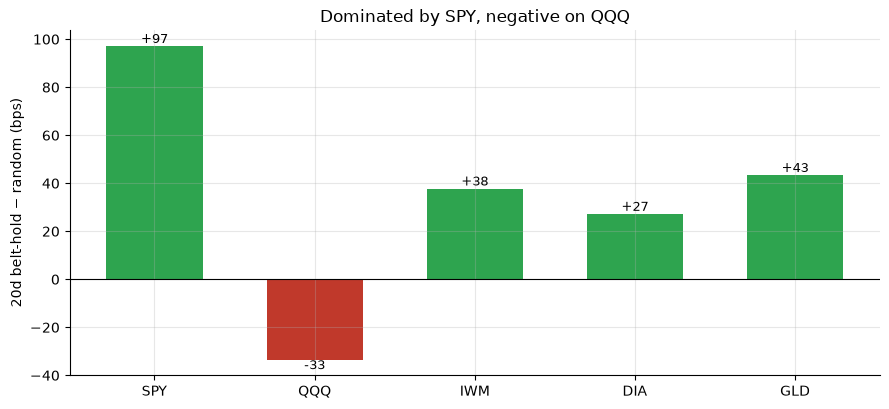

per-ticker 20d delta (bps): {'SPY': 97, 'QQQ': -33, 'IWM': 38, 'DIA': 27, 'GLD': 43}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)
        e = st.belt_hold_entries(c); re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d belt-hold − random (bps)'); ax.set_title('Dominated by SPY, negative on QQQ')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: **SPY** carries the result (+97 bps) while **QQQ** is **-34** bps *behind* random. No coherent, cross-sectional edge — the hallmark of a thin, context-driven tilt rather than a real candle signal.

### 4e · Synthetic positive control — the harness CAN bank a real reversal

To prove the marginal real result isn't a dead detector, plant a **real** post-belt-hold reversal into a synthetic tape and check the same rule banks it: edge=0 must stay at t≈0; edge>0 must light up.

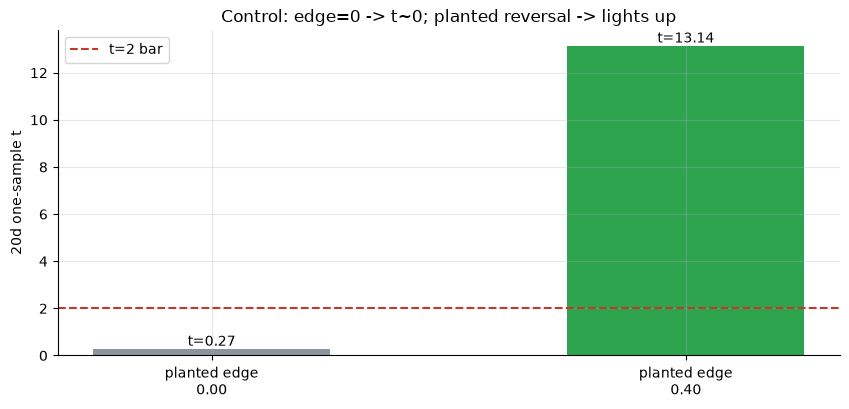

edge=0.00: n=200 bh=+11.5bps win=48% t=+0.27
edge=0.40: n=140 bh=+955.8bps win=92% t=+13.14


In [6]:
res = []
for edge in (0.0, 0.40):
    px, _ = data.synthetic_panel(edge=edge, seed=456, n_days=4000)
    e = st.belt_hold_entries(px); s = st.summarize(st.forward_returns(px, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted reversal -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} bh={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted reversal the control sits at **t = 0.27** (win 48% — no false positive); a planted reversal reaches **t = 13.14** (win 92%). The detector is live and sensitive — so the thin real-tape result is an honest reading, not a broken pipeline.

## 5 · The verdict

- **Signal `WEAK`** — the belt-hold is a coin-flip vs a drift-matched random baseline at 5/10/20d (Δ = -2/+9/+33 bps; Welch t ≤ 1.15) and only **marginally** beats random at 60d (Δ = +94 bps, Welch t = **+2.03**, p = 0.042). One horizon, right at the bar, concentrated in SPY. The big one-sample t's (20d **3.68**) are mostly beta.
- **Tradability `FRAGILE`** — the only vs-random edge is slow (60d), leans on one name, and is the downtrend context, not a deployable candle signal. Costs eat a thin result; nothing robust to scale.
- **Opening-extreme reverses? `BUSTED`** — the shape-scramble placebo leaves the result intact (**p = 0.43**): random downtrend bars do as well as the real belt-hold, so the open-at-the-low candle shape carries no forecasting information.

## 6 · Could you trade it? — there is barely anything to trade

The belt-hold's apparent profit is mostly the unconditional drift of long equity indices plus a thin, slow, single-name downtrend-reversion tilt — captured more simply by buying post-downtrend dips without a candle screener. The rule trades *less* of the time and pays costs on each signal, so it dominates almost nothing. There is no real capacity question because there is no robust edge to scale. The belt-hold is a descriptive candle label, not a forecasting strategy.

## 7 · Going further

- **Strip the candle.** The placebo says the residual is the downtrend. A clean follow-up buys post-downtrend dips with no shape filter and recovers the same 60d tilt — proving the candle is decorative.
- **Tighter geometry.** A full marubozu (no wicks either end), body ≥80% of range, or a stricter downtrend — fewer signals, same conclusion: context in, candle out.
- **Multiple-horizon honesty.** With 4 horizons tested, a single t = 2.03 at the longest is roughly what selection alone would produce; a Bonferroni/White reality-check would deflate it further.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*